## To look at distribution of tripos cells in Radbot horizontal data


In [15]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../IFCBData/SeaTrac/subsampled/radbot_ios/merged/D20230626T133109_IFCB110_merged_keepzero.csv")


In [10]:
from pathlib import Path
import pandas as pd

# -----------------------------
# User inputs
# -----------------------------
data_dir = Path("../IFCBData/SeaTrac/subsampled/radbot_ios/merged/")
output_csv = Path("../IFCBData/SeaTrac/subsampled/Tripos_muelleri_master.csv")

score_col = "Tripos_muelleri"
alpha = 0.9

# Optional: change this pattern if needed
file_pattern = "*.csv"

# -----------------------------
# Sweep files and collect matches
# -----------------------------
matched_rows = []

for file in data_dir.glob(file_pattern):
    df = pd.read_csv(file)

    if score_col not in df.columns:
        print(f"Skipping {file.name}: missing column {score_col}")
        continue

    df[score_col] = pd.to_numeric(df[score_col], errors="coerce")

    matched = df[df[score_col] > alpha].copy()

    if matched.empty:
        continue

    matched["source_file"] = file.name
    matched["source_path"] = str(file)

    matched_rows.append(matched)

# -----------------------------
# Compile master dataframe
# -----------------------------
if matched_rows:
    master_df = pd.concat(matched_rows, ignore_index=True)
else:
    master_df = pd.DataFrame()

# Save output
master_df.to_csv(output_csv, index=False)

print(f"Matched {len(master_df)} rows with {score_col} > {alpha}")
print(f"Saved to {output_csv}")

Matched 878 rows with Tripos_muelleri > 0.9
Saved to ../IFCBData/SeaTrac/subsampled/Tripos_muelleri_master.csv


In [13]:
df = pd.read_csv("../IFCBData/SeaTrac/subsampled/Tripos_muelleri_master.csv")


In [14]:
print(df.head())    


   trigger#  RoiNumber      PMTB    ADCtime    RunTime  InhibitTime  \
0         2          2  2.146278   9.468754   9.492296     0.085503   
1         4          4  2.038252  25.103766  25.126821     0.254264   
2         5          5  1.685771  32.505156  32.529421     0.340905   
3         9          9  2.114528  81.093912  81.119592     0.685781   
4        12         12  0.508774  90.534216  90.560009     0.940577   

   InhibitTimeDiff  VolumeAnalyzed  RoiType  RoiHeight  ...  fiber  \
0         0.085503        0.039195        1        508  ...    0.0   
1         0.084110        0.103636        1        580  ...    0.0   
2         0.086641        0.134119        1        532  ...    0.0   
3         0.087810        0.335141        1        548  ...    0.0   
4         0.085193        0.373414        1        476  ...    0.0   

   fiber_TAG_external_detritus  flagellate flagellate_morphotype1  \
0                          0.0         0.0                    0.0   
1             

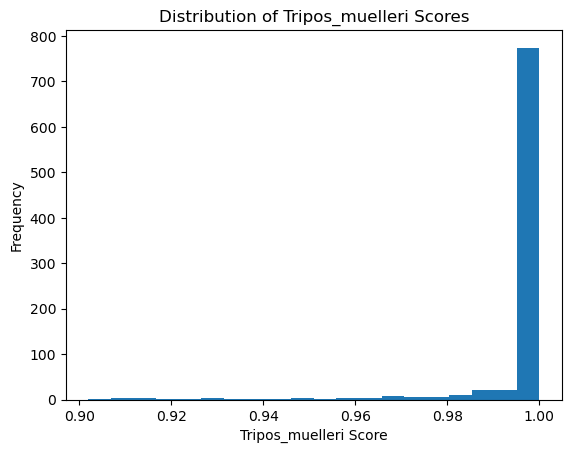

In [16]:
plt.hist(df["Tripos_muelleri"], bins=20)
plt.xlabel("Tripos_muelleri Score")
plt.ylabel("Frequency")
plt.title("Distribution of Tripos_muelleri Scores")
plt.show()  

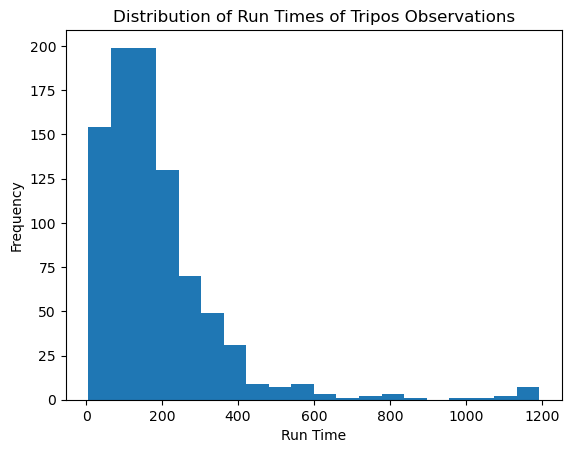

In [19]:
plt.hist(df["RunTime"], bins=20)
plt.xlabel("Run Time")
plt.ylabel("Frequency")
plt.title("Distribution of Run Times of Tripos Observations")
plt.savefig("../Figs/TriposRunTimeDistribution.png")
plt.show()  